In [1]:
from SCFT_DNA.SCFT_functions import *
from SCFT_DNA.DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import hictkpy as htk
from matplotlib.colors import LogNorm

from pathlib import Path

from Bead_sequence_MC.mf_chromatin_functions import *
from scipy.stats import pearsonr

Using cupy


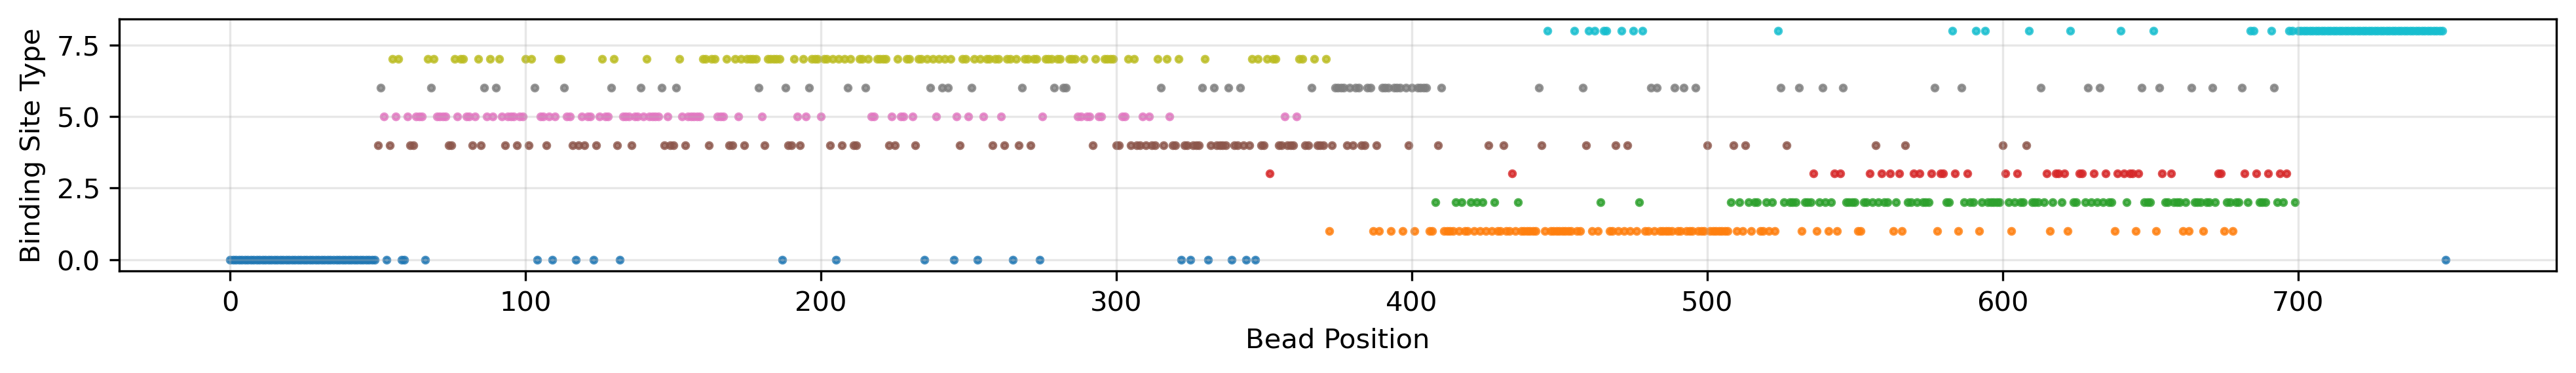

In [2]:
ns = 750
chain_interaction_binary = IMR90_data(ns, split_class_zero=True)

In [3]:
chi_pp = 900*xp.ones((chain_interaction_binary.shape[0],chain_interaction_binary.shape[0]))
chi_ps = 950*xp.ones(chain_interaction_binary.shape[0])

N = 1000

nx = ny = 128
initial_qsr = xp.ones((nx, ny))
L = 56 #dimension of the box

width_gaussian = nx // 4
x = np.linspace(-1, 1, width_gaussian)
y = np.linspace(-1, 1, width_gaussian)
X, Y = np.meshgrid(x, y, indexing='ij')
gaussian = np.exp(-(X**2 + Y**2)/0.1)
boundary = np.zeros((nx,ny))
boundary[nx//2-width_gaussian//2:nx//2+width_gaussian//2,nx//2-width_gaussian//2:nx//2+width_gaussian//2] += gaussian

boundary = xp.random.rand(nx,ny)

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.1, # volume fraction of polymer
    l_p=xp.sqrt(N),
    n_seg=1, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=7000,
    error_tol=1e-12,
    chain_interaction=xp.asarray(chain_interaction_binary),
    self_avoiding=0,
    initial_qsr=xp.array(boundary),
    mixing_rate=0.004,
    chi_polymer_block = chi_pp,
    chi_polymer_s = chi_ps,
    PB = 1,
    close_boundary=True,
)

In [4]:
data = np.load("../chi_n_900_950.npz")

wsr = data["wsr"]
phi = data["phi"]
phi_blocks = data["phi_blocks"]
qsr = data["qsr"]
qsr_d = data["qsr_d"]
diff = data["diff"]
free_energy_hist = data["free_energy_hist"]

In [27]:
phi_sr = qsr*qsr_d/np.mean(qsr*qsr_d)

In [16]:
def pair_correlation_2D(rho):
    ns_plus_1 = rho.shape[0]
    correlation_function = np.zeros((ns_plus_1, ns_plus_1))

    #rho = rho/np.mean(rho, axis = (1,2))[:, None, None]
    rho = rho/np.mean(rho)

    for i in prange(ns_plus_1):
        for k in prange(ns_plus_1):
            correlation_function[i, k] = np.sum(rho[i] * rho[k])

    return correlation_function

In [17]:
corr_2d = pair_correlation_2D(to_numpy(qsr*qsr_d))

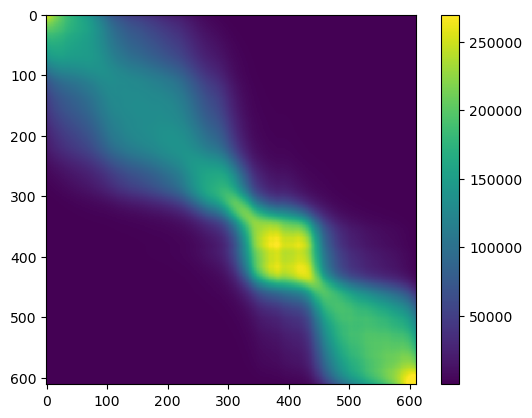

In [21]:
crop_range = 70
corr_2d_crop = corr_2d[crop_range:-crop_range, crop_range:-crop_range]
dynamic_range = 4 * np.std(corr_2d_crop)
plt.imshow(corr_2d_crop, cmap='viridis', interpolation='nearest', aspect=1,
           #vmin=-dynamic_range,
           vmax=+dynamic_range
           )

plt.colorbar()

In [22]:
def diagonal_decay_profile(A, agg="mean", normalize=True):
    """
    A: square matrix (N x N), ideally symmetric
    agg: "mean", "median", or a callable reducing 1D arrays -> scalar
    normalize: if True, divide by the k=0 value
    Returns:
        profile: length-N array, average intensity vs. distance k from diagonal
        horiz:   length-N array, average of super-diagonals  (offset +k)
        vert:    length-N array, average of sub-diagonals    (offset -k)
    """
    A = np.asarray(A)
    assert A.ndim == 2 and A.shape[0] == A.shape[1], "A must be square"
    N = A.shape[0]

    if agg == "mean":
        reducer = np.nanmean
    elif agg == "median":
        reducer = np.nanmedian
    elif callable(agg):
        reducer = agg
    else:
        raise ValueError("agg must be 'mean', 'median', or a callable")

    # horizontal: values k to the right of each diagonal element → super-diagonals
    horiz = np.array([reducer(np.diagonal(A, offset=k)) for k in range(N)])
    # vertical: values k below each diagonal element → sub-diagonals
    vert  = np.array([reducer(np.diagonal(A, offset=-k)) for k in range(N)])

    # Combine horizontal+vertical for each k (k=0 is just the main diagonal once)
    profile = horiz.copy()
    # For k>0, average super and sub diagonals together
    profile[1:] = 0.5 * (horiz[1:] + vert[1:])

    if normalize and profile[0] != 0:
        norm = profile / profile[0]
    else:
        norm = profile

    return norm, horiz, vert

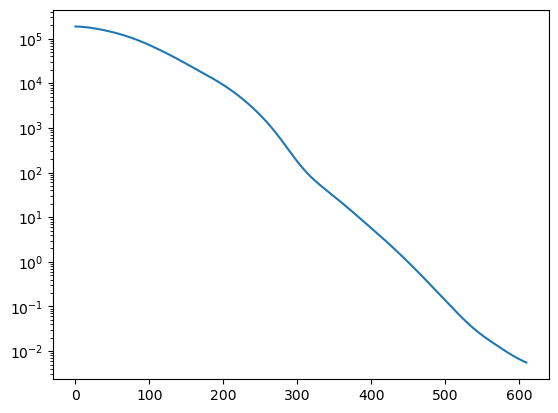

In [24]:
decay, horiz, vert = diagonal_decay_profile(corr_2d_crop, agg="mean", normalize=False)
plt.plot(decay, label = "Hi-C")
plt.yscale("log")

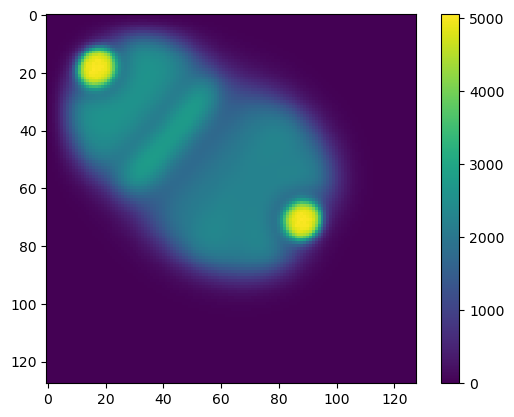

In [29]:
plt.imshow(np.sum(phi_sr, axis=0), cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

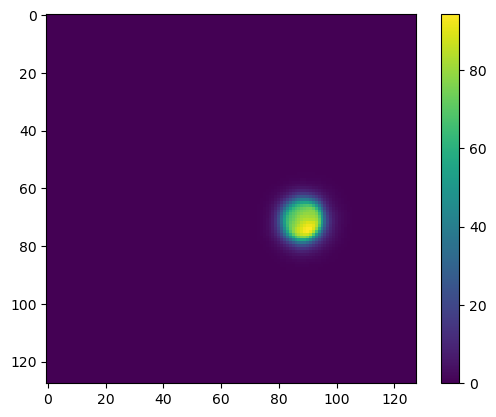

In [33]:
plt.imshow(phi_sr[2], cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

In [48]:
def com_2D(phi):
    x_coord = np.arange(phi.shape[0])
    y_coord = np.arange(phi.shape[1])

    x_com = np.sum(x_coord * np.sum(phi, axis=1))/np.sum(phi)
    y_com = np.sum(y_coord * np.sum(phi, axis=0))/np.sum(phi)
    return np.array([x_com, y_com], dtype=int)

In [49]:
com = com_2D(phi_sr[2])
print(com)

[71 88]


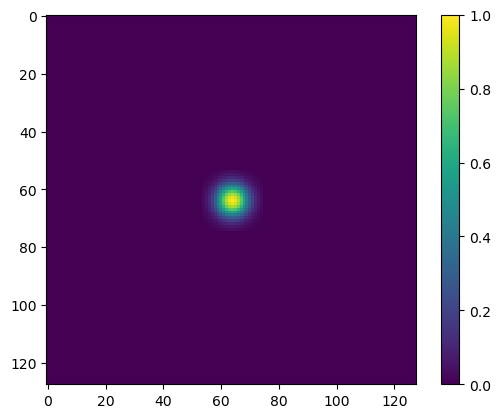

In [46]:
width_gaussian = nx // 6
x = np.linspace(-1, 1, width_gaussian)
y = np.linspace(-1, 1, width_gaussian)
X, Y = np.meshgrid(x, y, indexing='ij')
gaussian = np.exp(-(X**2 + Y**2)/0.3)
boundary = np.zeros((nx,ny))
boundary[nx//2-width_gaussian//2:nx//2-width_gaussian//2+width_gaussian,ny//2-width_gaussian//2:ny//2-width_gaussian//2+width_gaussian] += gaussian

plt.imshow(boundary, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

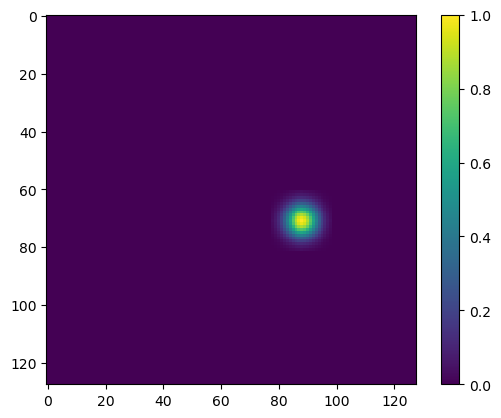

In [52]:
boundary_shift_com = np.roll(boundary, com-np.array([nx//2, ny//2]), axis = (0,1))

plt.imshow(boundary_shift_com, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

In [94]:
def gaussian_com_2d(phi):

    x_coord = np.arange(phi.shape[0])
    y_coord = np.arange(phi.shape[1])

    x_com = np.sum(x_coord * np.sum(phi, axis=1))/np.sum(phi)
    y_com = np.sum(y_coord * np.sum(phi, axis=0))/np.sum(phi)
    com = np.array([x_com, y_com])

    width_gaussian = phi.shape[0]

    x_coord = np.arange(phi.shape[0])
    y_coord = np.arange(phi.shape[1])
    X,Y = np.meshgrid(x_coord, y_coord, indexing='ij')
    gaussian = np.exp(-((X-com[0])**2 + (Y-com[1])**2)/width_gaussian)
    return gaussian

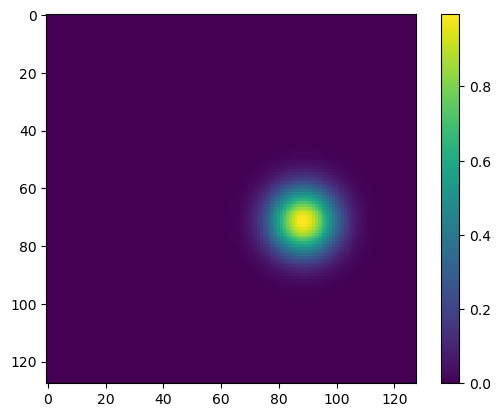

In [95]:
gaussian_com = gaussian_com_2d(phi_sr[2])
plt.imshow(gaussian_com, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

(1280, 1280)


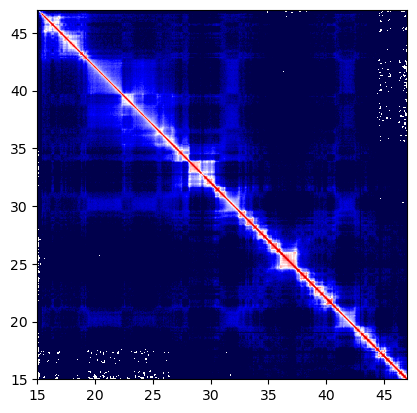

In [2]:
#hic_path = r"/Bead_sequence_MC/GSE63525_IMR90_combined_30.hic"
hic_path = Path.cwd().parent.parent / "Bead_sequence_MC" / "GSE63525_IMR90_combined_30.hic"

bin_size = 25_000
f = htk.File(hic_path, bin_size)

extent = (15,47,15,47)
sel = f.fetch("21:15,000,000-47,000,000")
m = sel.to_numpy()
#plt.imshow(np.log10(m), cmap="Reds",)
plt.imshow(m, norm=LogNorm(),cmap="seismic",extent=extent)
print(m.shape)

In [6]:
np.save("../../Bead_sequence_MC/chr21_15_47.npy", m)

(600, 600)


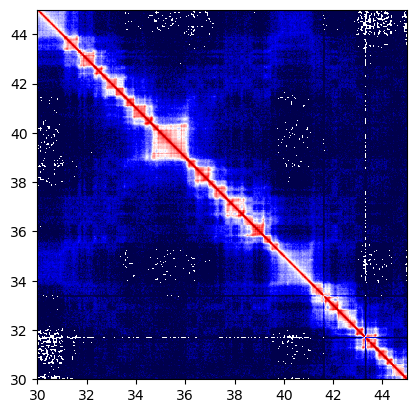

In [3]:
hic_path = Path.cwd().parent.parent / "Bead_sequence_MC" / "GSE63525_IMR90_combined_30.hic"

bin_size = 25_000
f = htk.File(hic_path, bin_size)

start = 30
end = 45
offset = 1.35
#extent = (start+offset,end+offset,start+offset,end+offset)
extent = (start,end,start,end)
select_start = int((start + offset)*1e6)
select_end = int((end + offset)*1e6)
sel = f.fetch(f"21:{select_start}-{select_end}")
m = sel.to_numpy()
#plt.imshow(np.log10(m), cmap="Reds",)
plt.imshow(m, norm=LogNorm(),cmap="seismic",extent=extent)
print(m.shape)

(480, 480)


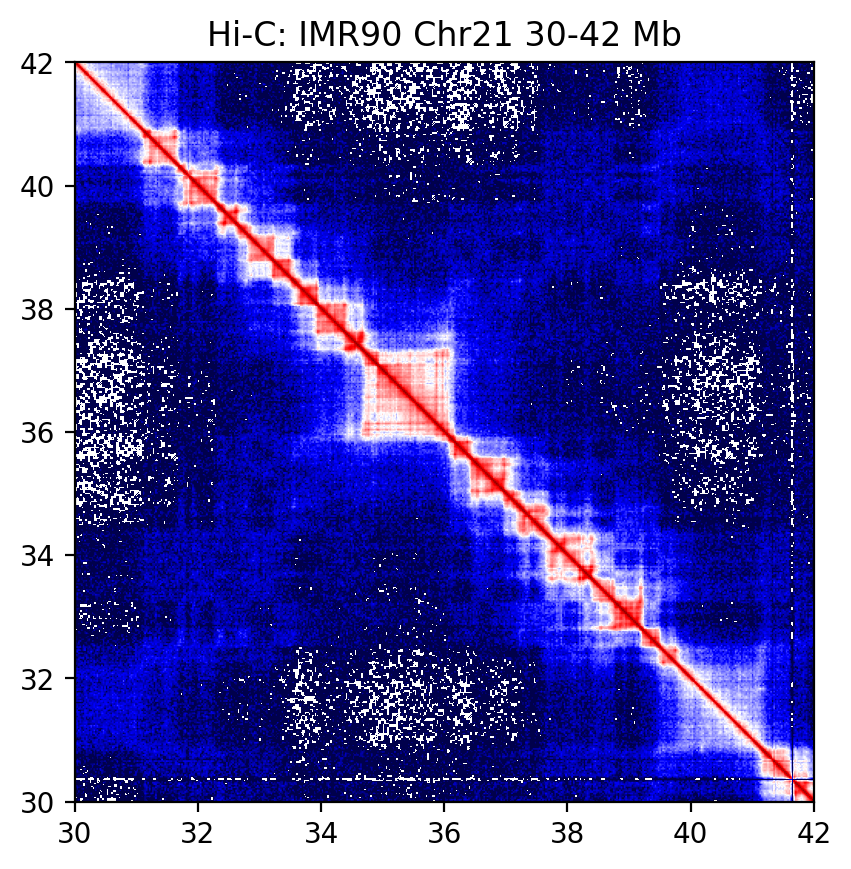

In [4]:
hic_path = Path.cwd().parent.parent / "Bead_sequence_MC" / "GSE63525_IMR90_combined_30.hic"

bin_size = 25_000
f = htk.File(hic_path, bin_size)

start = 30
end = 42
offset = 1.35
#extent = (start+offset,end+offset,start+offset,end+offset)
extent = (start,end,start,end)
select_start = int((start + offset)*1e6)
select_end = int((end + offset)*1e6)
sel = f.fetch(f"21:{select_start}-{select_end}")
m = sel.to_numpy()

plt.figure(dpi=200)
plt.imshow(m, norm=LogNorm(),cmap="seismic",extent=extent)
plt.title("Hi-C: IMR90 Chr21 30-42 Mb")

print(m.shape)

In [26]:
np.save("../../Bead_sequence_MC/chr21_30_42.npy", m)